### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear un diccionario con las tiendas
tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

# Verificar estructura básica de cada tienda
for nombre, df in tiendas.items():
    print(f'\n{nombre}')
    print(df.head())
    print(df.info())
    print(df.isnull().sum())


Tienda 1
            Producto Categoría del Producto    Precio  Costo de envío  \
0  Asistente virtual           Electrónicos  164300.0          6900.0   
1    Mesa de comedor                Muebles  192300.0          8400.0   
2      Juego de mesa               Juguetes  209600.0         15900.0   
3         Microondas      Electrodomésticos  757500.0         41000.0   
4   Silla de oficina                Muebles  335200.0         20200.0   

  Fecha de Compra         Vendedor Lugar de Compra  Calificación  \
0      16/01/2021      Pedro Gomez          Bogotá             4   
1      18/05/2022  Beatriz Morales        Medellín             1   
2      15/03/2021   Juan Fernandez       Cartagena             1   
3      03/05/2022   Juan Fernandez            Cali             4   
4      07/11/2020    Maria Alfonso        Medellín             5   

       Método de pago  Cantidad de cuotas       lat       lon  
0  Tarjeta de crédito                   8   4.60971 -74.08175  
1  Tarjeta de 

#1. Análisis de facturación



Facturación total por tienda:
     Tienda   Facturación
0  Tienda 1  1.150880e+09
1  Tienda 2  1.116344e+09
2  Tienda 3  1.098020e+09
3  Tienda 4  1.038376e+09


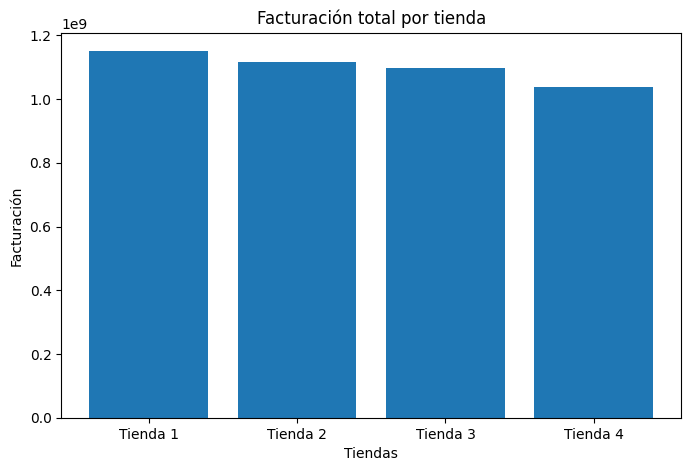

In [3]:
# Facturación total por tienda
facturacion = {}

for nombre, df in tiendas.items():
    facturacion[nombre] = df['Precio'].sum()

facturacion_df = pd.DataFrame(list(facturacion.items()), columns=['Tienda', 'Facturación'])
print("Facturación total por tienda:")
print(facturacion_df)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(facturacion_df['Tienda'], facturacion_df['Facturación'])
plt.title('Facturación total por tienda')
plt.xlabel('Tiendas')
plt.ylabel('Facturación')
plt.xticks(rotation=0)
plt.show()

# 2. Ventas por categoría


Ventas por categoría - Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Ventas por categoría - Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Ventas por categoría - Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Ventas po

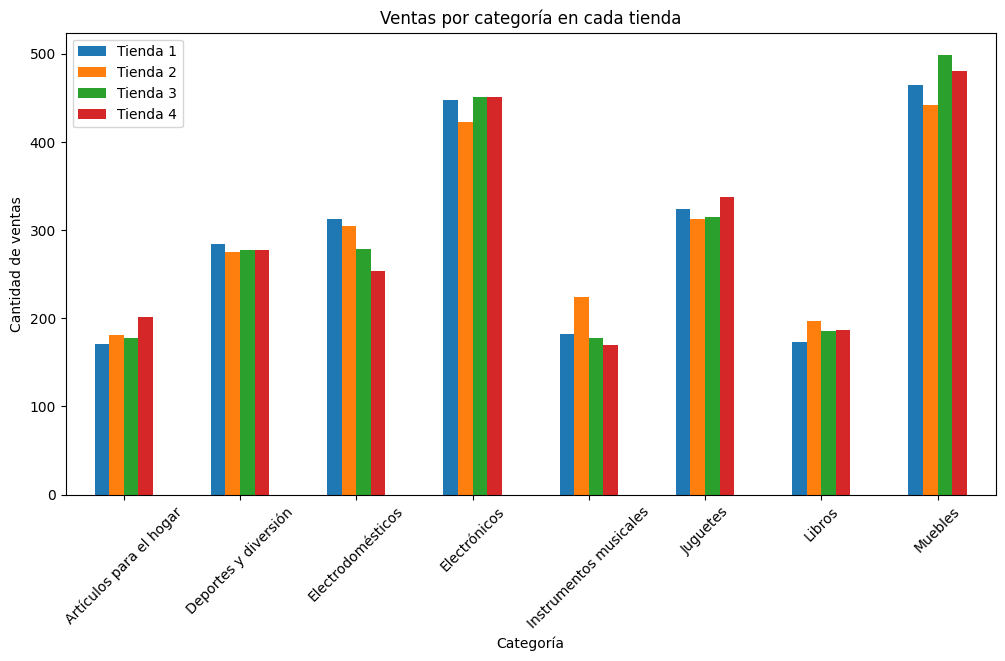

In [4]:
# Ventas por categoría por tienda
categorias_tiendas = {}

for nombre, df in tiendas.items():
    categorias_tiendas[nombre] = df['Categoría del Producto'].value_counts()

for nombre, categorias in categorias_tiendas.items():
    print(f'\nVentas por categoría - {nombre}')
    print(categorias)

# Unificar categorías en un DataFrame
categorias_df = pd.DataFrame(categorias_tiendas).fillna(0)
print("\nResumen general de ventas por categoría:")
print(categorias_df)

# Gráfico de barras agrupadas
categorias_df.plot(kind='bar', figsize=(12,6))
plt.title('Ventas por categoría en cada tienda')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de ventas')
plt.xticks(rotation=45)
plt.show()

# 3. Calificación promedio de la tienda


Calificación promedio por tienda:
     Tienda  Calificación Promedio
0  Tienda 1               3.976685
1  Tienda 2               4.037304
2  Tienda 3               4.048326
3  Tienda 4               3.995759


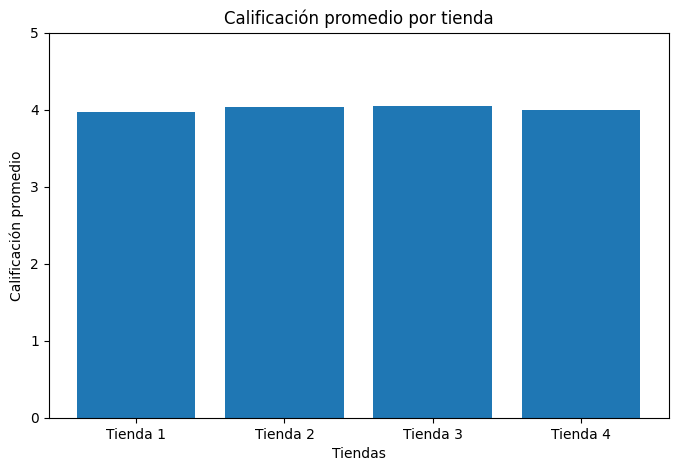

In [5]:
# Clasificación promedio por tienda
calificacion_promedio = {}

for nombre, df in tiendas.items():
    calificacion_promedio[nombre] = df['Calificación'].mean()

calificacion_df = pd.DataFrame(list(calificacion_promedio.items()), columns=['Tienda', 'Calificación Promedio'])
print("Calificación promedio por tienda:")
print(calificacion_df)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(calificacion_df['Tienda'], calificacion_df['Calificación Promedio'])
plt.title('Calificación promedio por tienda')
plt.xlabel('Tiendas')
plt.ylabel('Calificación promedio')
plt.ylim(0, 5)
plt.show()

# 4. Productos más y menos vendidos

In [6]:
# Productos más y menos vendidos por tienda
for nombre, df in tiendas.items():
    conteo_productos = df['Producto'].value_counts()

    producto_mas_vendido = conteo_productos.idxmax()
    cantidad_mas_vendido = conteo_productos.max()

    producto_menos_vendido = conteo_productos.idxmin()
    cantidad_menos_vendido = conteo_productos.min()

    print(f'\n{nombre}')
    print(f'Producto más vendido: {producto_mas_vendido} ({cantidad_mas_vendido} ventas)')
    print(f'Producto menos vendido: {producto_menos_vendido} ({cantidad_menos_vendido} ventas)')


Tienda 1
Producto más vendido: Microondas (60 ventas)
Producto menos vendido: Auriculares con micrófono (33 ventas)

Tienda 2
Producto más vendido: Iniciando en programación (65 ventas)
Producto menos vendido: Juego de mesa (32 ventas)

Tienda 3
Producto más vendido: Kit de bancas (57 ventas)
Producto menos vendido: Bloques de construcción (35 ventas)

Tienda 4
Producto más vendido: Cama box (62 ventas)
Producto menos vendido: Guitarra eléctrica (33 ventas)


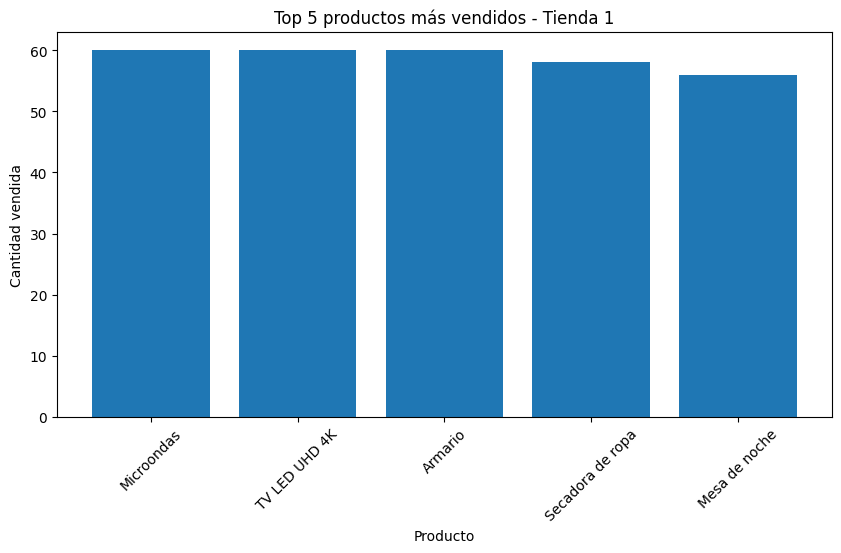

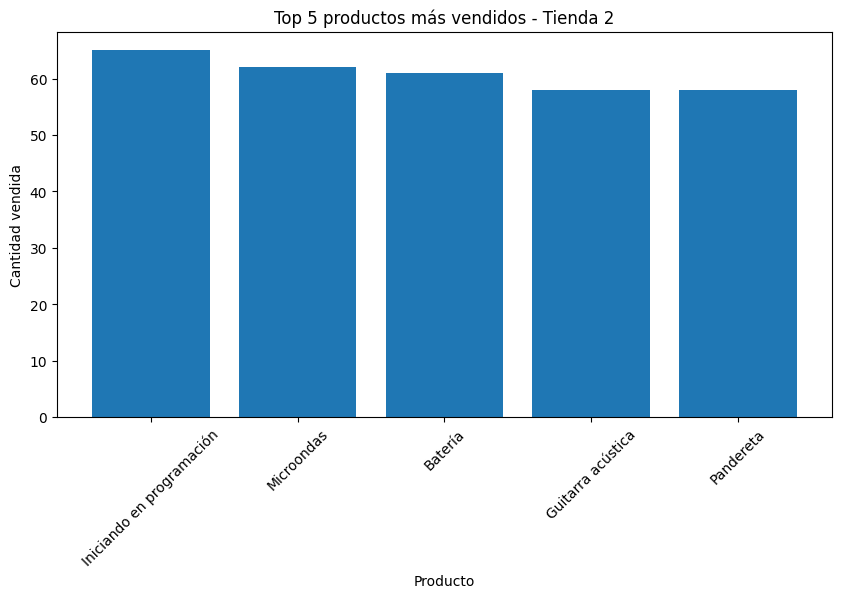

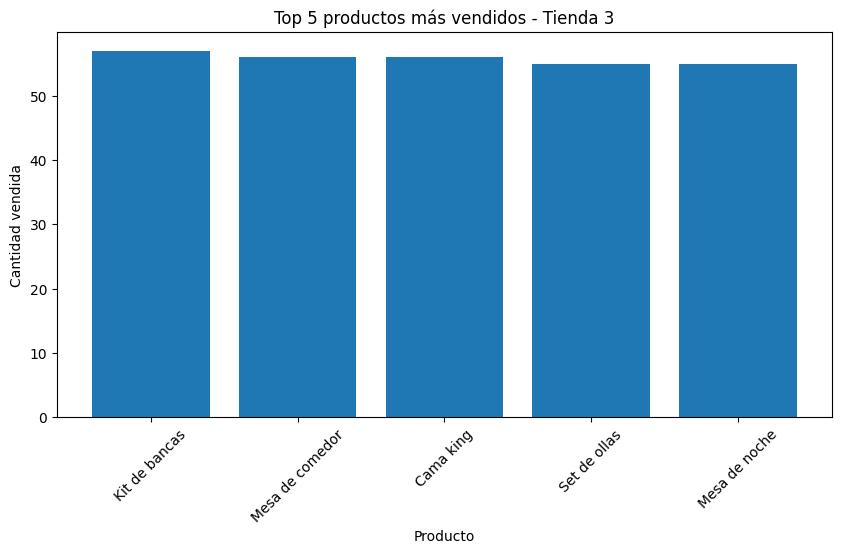

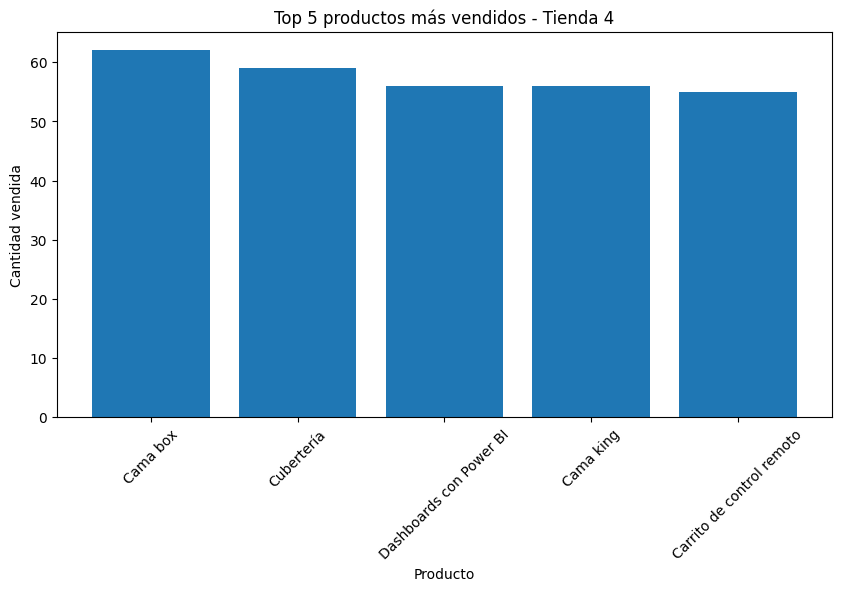

In [7]:
# Gráfico de los 5 productos más vendidos por tienda
for nombre, df in tiendas.items():
    top5 = df['Producto'].value_counts().head(5)

    plt.figure(figsize=(10,5))
    plt.bar(top5.index, top5.values)
    plt.title(f'Top 5 productos más vendidos - {nombre}')
    plt.xlabel('Producto')
    plt.ylabel('Cantidad vendida')
    plt.xticks(rotation=45)
    plt.show()

# 5. Envío promedio por tienda

Costo de envío promedio por tienda:
     Tienda  Envío Promedio
0  Tienda 1    26018.609580
1  Tienda 2    25216.235693
2  Tienda 3    24805.680373
3  Tienda 4    23459.457167


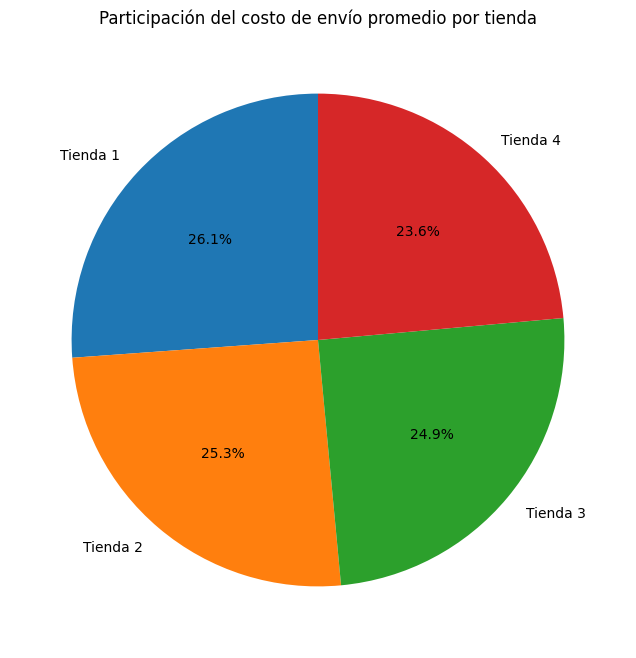

In [8]:
# Envío promedio por tienda
envio_promedio = {}

for nombre, df in tiendas.items():
    envio_promedio[nombre] = df['Costo de envío'].mean()

envio_df = pd.DataFrame(list(envio_promedio.items()), columns=['Tienda', 'Envío Promedio'])
print("Costo de envío promedio por tienda:")
print(envio_df)

# Gráfico circular
plt.figure(figsize=(8,8))
plt.pie(envio_df['Envío Promedio'], labels=envio_df['Tienda'], autopct='%1.1f%%', startangle=90)
plt.title('Participación del costo de envío promedio por tienda')
plt.show()

In [9]:
# Resumen general consolidado
resumen = pd.DataFrame({
    'Facturación': facturacion,
    'Calificación Promedio': calificacion_promedio,
    'Envío Promedio': envio_promedio
})

print("Resumen general de desempeño por tienda:")
print(resumen)

Resumen general de desempeño por tienda:
           Facturación  Calificación Promedio  Envío Promedio
Tienda 1  1.150880e+09               3.976685    26018.609580
Tienda 2  1.116344e+09               4.037304    25216.235693
Tienda 3  1.098020e+09               4.048326    24805.680373
Tienda 4  1.038376e+09               3.995759    23459.457167


#  Informe Final — Análisis de Tiendas Alura Store

## Introducción

En este análisis se evaluó el desempeño de las cuatro tiendas de la cadena **Alura Store** con el objetivo de determinar cuál de ellas debería vender el Sr. Juan para iniciar un nuevo emprendimiento.

Para tomar esta decisión se analizaron varios indicadores importantes del negocio:

- Facturación total de cada tienda
- Ventas por categoría de productos
- Calificación promedio de los clientes
- Productos más vendidos
- Costo de envío promedio

Estos factores permiten entender tanto el rendimiento económico de cada tienda como la experiencia de los clientes.

---

##  Análisis de Facturación

La facturación total de cada tienda fue calculada sumando el valor de todas las ventas registradas.

**Resultados:**

- **Tienda 1:** 1.150.880.000  
- **Tienda 2:** 1.116.344.000  
- **Tienda 3:** 1.098.020.000  
- **Tienda 4:** 1.038.376.000  

Se observa que **Tienda 1 genera los mayores ingresos**, mientras que **Tienda 4 presenta la facturación más baja**, lo que indica un menor rendimiento en ventas.

---

##  Ventas por Categoría

El análisis por categorías permitió entender qué tipo de productos tienen mayor demanda en las tiendas.

Las categorías con mayor volumen de ventas fueron:

- **Muebles**
- **Electrónicos**
- **Juguetes**

Observaciones importantes:

- **Tienda 3** destaca especialmente en la venta de **muebles**.
- **Tienda 1 y Tienda 4** tienen buen desempeño en **electrónicos**.
- **Tienda 2** presenta más ventas en **instrumentos musicales**.

Sin embargo, **la Tienda 4 no lidera claramente ninguna categoría**, lo que sugiere un rendimiento comercial más bajo frente a las demás tiendas.

---

##  Calificación Promedio de Clientes

Las calificaciones promedio obtenidas fueron:

- **Tienda 1:** 3.98  
- **Tienda 2:** 4.04  
- **Tienda 3:** 4.05  
- **Tienda 4:** 4.00  

Las diferencias entre tiendas no son muy grandes, pero se puede notar que:

- **Tienda 3 tiene la mejor valoración de clientes**
- **Tienda 1 tiene la calificación promedio más baja**

En general, todas las tiendas mantienen una valoración cercana a **4 estrellas**, lo que indica un buen nivel de satisfacción.

---

##  Productos Más Vendidos

El análisis de los productos más vendidos permitió identificar los artículos con mayor demanda.

**Tienda 1**
- Microondas  
- TV LED UHD 4K  
- Armario  
- Secadora de ropa  
- Mesa de noche  

**Tienda 2**
- Microondas  
- Batería  
- Guitarra acústica  
- Pandereta  

**Tienda 3**
- Kit de bancas  
- Mesa de comedor  
- Cama King  
- Set de ollas  

**Tienda 4**
- Cama Box  
- Cubertería  
- Dashboards con Power BI  
- Cama King  

En general, los productos relacionados con **muebles y electrodomésticos** presentan una alta demanda.

---

##  Costo de Envío Promedio

Los costos de envío promedio fueron:

- **Tienda 1:** 26.018  
- **Tienda 2:** 25.216  
- **Tienda 3:** 24.805  
- **Tienda 4:** 23.459  

Aunque **Tienda 4 tiene el costo de envío más bajo**, este beneficio no se refleja en un mayor volumen de ventas.

---

#  Conclusión

Después de analizar todos los indicadores —facturación, ventas por categoría, calificaciones de clientes, productos más vendidos y costos de envío— se puede concluir que **la Tienda 4 presenta el rendimiento más bajo dentro de la cadena Alura Store**.

Las principales razones son:

- Tiene **la menor facturación total**
- No lidera en ninguna categoría de ventas
- Su desempeño general es inferior al de las demás tiendas

Por lo tanto, **se recomienda que el Sr. Juan venda la Tienda 4**, ya que es la que aporta menos ingresos al negocio.

Esto permitirá concentrar los recursos en las tiendas con mejor rendimiento y mayor potencial de crecimiento.

